Introduction to scikit-learn

Goal: Introduce scikit-learn for machine learning preprocessing and basic modeling.

In [1]:
# 1.Importing scikit-learn
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
# 2.Loading a Sample Dataset
from sklearn.datasets import load_iris
iris =load_iris()
x=iris.data
y=iris.target

In [3]:
# 3.Train-Test Split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [4]:
# 4.Train a Logistic Regression Model
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [6]:
# 5.Make Predictions
y_pred=model.predict(x_test)

In [8]:
# 6.Model Accuracy Score
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

1.0


In [9]:
# 7.Confusion Matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [11]:
# 8.Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
# 9.Standardize Features (StandardScaler)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [13]:
# 10.Label Encoding
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y_encoded=encoder.fit_transform(y)

In [15]:
# 11.Train a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()
tree.fit(x_train,y_train)

DecisionTreeClassifier()

In [18]:
# 12.Train a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [22]:
# 13.Cross-Validation Score
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print("Mean Accuracy : ",scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Mean Accuracy :  0.9733333333333334


In [23]:
# 14.Pipeline with Preprocessing + Model
from sklearn.pipeline import Pipeline
pipe=Pipeline([('scaler',StandardScaler()),('classifier',LogisticRegression())])
pipe.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceba

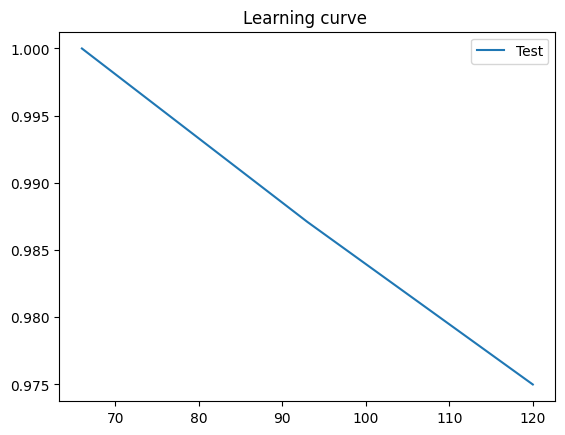

In [29]:
# 15.Plot Learning Curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
train_sizes,train_scores,test_scores=learning_curve(model,x,y,cv=5,train_sizes=np.linspace(0.1,1.0,5))
plt.plot(train_sizes,train_scores.mean(axis=1),label='Test')
plt.legend()
plt.title("Learning curve ")
plt.show()
